In [1]:
!git clone https://github.com/yandex-research/switti.git .switti

Cloning into '.switti'...
remote: Enumerating objects: 240, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 240 (delta 25), reused 30 (delta 11), pack-reused 192 (from 2)
Receiving objects: 100% (240/240), 144.34 MiB | 15.42 MiB/s, done.
Resolving deltas: 100% (81/81), done.


In [3]:
%%bash

cat > .switti/utils/arg_util.py << 'EOF'
RESOLUTION_PATCH_NUMS_MAPPING = {
    256: "1_2_3_4_5_6_8_10_13_16",
    512: "1_2_3_4_6_9_13_18_24_32",
    1024: "1_2_3_4_5_7_9_12_16_21_27_36_48_64",
}
EOF

In [4]:
!pip install -r .switti/requirements.txt

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-89s2ir53
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-89s2ir53
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.3/266.3 kB 28.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.5/447.5 kB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 100.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 94.9 MB/s eta 0:00:00
   ━━━━━━━━━━

In [5]:
import sys
sys.path.append(".switti")

import torch

from models import SwittiPipeline

/content/.switti/models/basic_switti.py:25: UserWarning: Cannot import apex RMSNorm, switch to vanilla implementation
  warnings.warn("Cannot import apex RMSNorm, switch to vanilla implementation")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/146 [00:00<?, ?B/s]


[constructor]  ==== fused_if_available=True (fusing_add_ln=0/30, fusing_mlp=0/30) ==== 
    [Switti config ] embed_dim=1920, num_heads=30, depth=30, mlp_ratio=4.0
    [drop ratios ] drop_rate=0.0, attn_drop_rate=0.0, drop_path_rate=0 (tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0.]))



model.safetensors:   0%|          | 0.00/9.90G [00:00<?, ?B/s]

config.json:   0%|          | 0.00/201 [00:00<?, ?B/s]

...

pytorch_model.bin.index.json: 0.00B [00:00, ?B/s]

pytorch_model-00001-of-00002.bin:   0%|          | 0.00/9.99G [00:00<?, ?B/s]

pytorch_model-00002-of-00002.bin:   0%|          | 0.00/169M [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

/content/.switti/models/rope.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


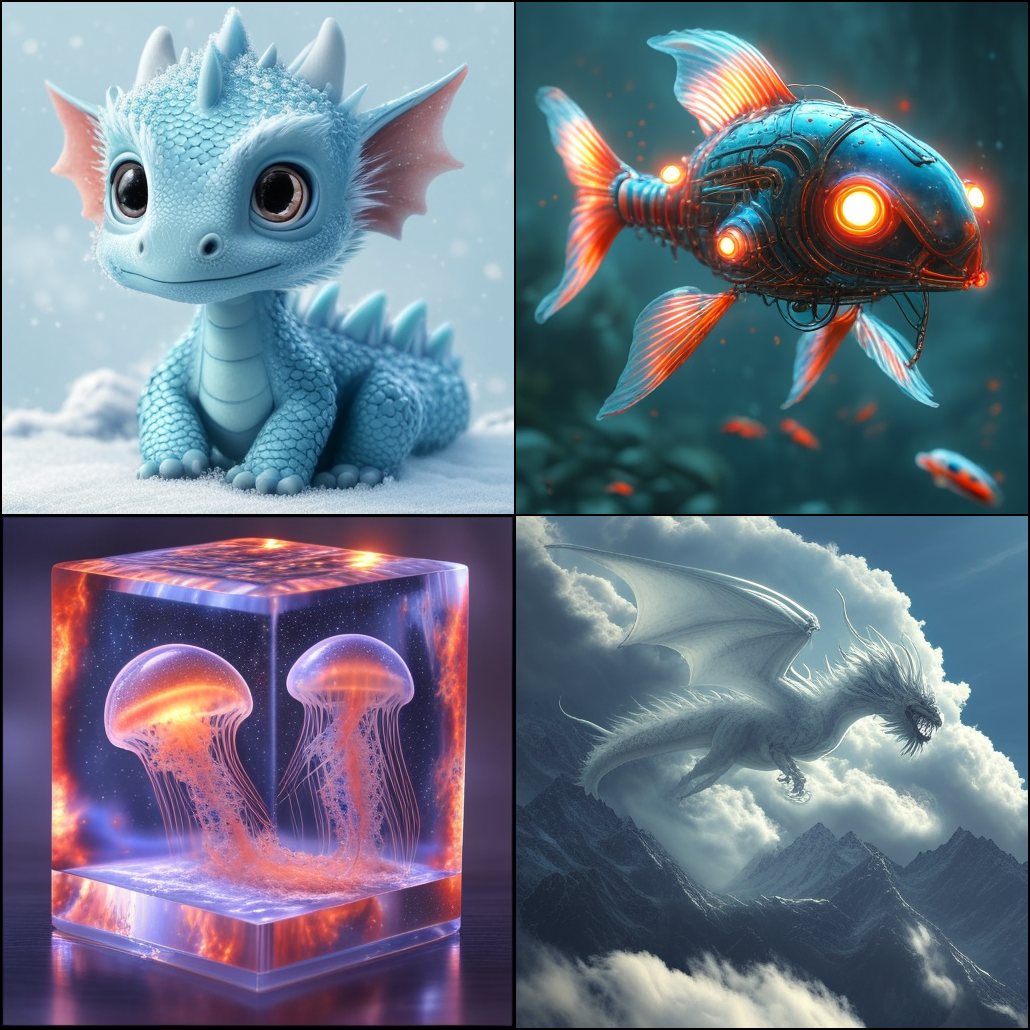

In [6]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


model_path = "yresearch/Switti"
dtype = torch.bfloat16 if DEVICE.type != 'cpu' else torch.float32

pipe = SwittiPipeline.from_pretrained(model_path, device=DEVICE, torch_dtype=dtype, reso=512)

from torchvision.utils import make_grid
from torchvision.transforms.functional import to_pil_image

prompts = ["Cute winter dragon baby, kawaii, Pixar, ultra detailed, glacial background, extremely realistic",
           "flying robot koi fish with armour plating, neon glowing eyes and wiring, 4k, unreal engine, marvel comics style",
           "sci-fi cosmic diarama of a quasar and jellyfish in a resin cube, volumetric lighting, high resolution, hdr, sharpen, Photorealism",
           "A cloud dragon flying over mountains, its body swirling with the wind.",
          ]
images = pipe(prompts,
              cfg=6.0,
              top_k=400,
              top_p=0.95,
              more_smooth=True,
              return_pil=False,
              smooth_start_si=2,
              turn_on_cfg_start_si=2,
              turn_off_cfg_start_si=8,
              last_scale_temp=0.1,
              seed=59,
             )
to_pil_image(make_grid([img.float() for img in images], nrow=2))